# Tarea 1: Clasificación supervisada multiclase

En este notebook se desarrolla la tarea de clasificación supervisada del proyecto. El objetivo es predecir la variable `objetivo`, que indica la situación final del estudiante: `abandono`, `matriculado` o `graduado`.

El flujo seguido es: carga de datos, separación de variables, preprocesamiento, división train/test, comparación de modelos, evaluación final e interpretación mediante permutation importance.

## 1. Importación de librerías

Se importan las librerías necesarias para cargar los datos, construir pipelines de preprocesamiento, entrenar modelos de clasificación y evaluar su rendimiento. También se importan herramientas de visualización para representar la matriz de confusión y la importancia de variables.

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## 2. Carga de datos y exploración inicial

In [4]:
df = pd.read_csv("rendimiento_estudiantes.csv", sep=";")

print("Dimensiones del dataset:", df.shape)
print("\nDistribución de la variable objetivo:")
print(df["objetivo"].value_counts())

Dimensiones del dataset: (4424, 37)

Distribución de la variable objetivo:
objetivo
graduado       2209
abandono       1421
matriculado     794
Name: count, dtype: int64


## 3. Separación entre variables predictoras y variable objetivo

Se define `X` como el conjunto de variables predictoras, eliminando la columna `objetivo`. Por otro lado, `y` contiene la clase real que se desea predecir.

Después, las variables se separan en categóricas y numéricas. Esta separación es necesaria porque cada tipo de variable requiere un preprocesamiento distinto.

In [5]:
X = df.drop(columns=["objetivo"])
y = df["objetivo"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variables categóricas:", len(cat_cols))
print("Variables numéricas:", len(num_cols))

Variables categóricas: 17
Variables numéricas: 19


## 4. Preprocesamiento de los datos

Se construye un preprocesador distinto para variables numéricas y categóricas.

Para las variables numéricas, se imputan valores faltantes con la mediana y se estandarizan. Para las variables categóricas, se imputan valores faltantes con la categoría más frecuente y se aplica `OneHotEncoder`.

El uso de `ColumnTransformer` permite aplicar automáticamente cada transformación al tipo de columna correspondiente.

In [6]:
transformar_numericas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformar_categoricas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", transformar_numericas, num_cols),
    ("cat", transformar_categoricas, cat_cols)
])

## 5. División en entrenamiento y test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de test:", X_test.shape)

Tamaño de entrenamiento: (3539, 36)
Tamaño de test: (885, 36)


## 6. Definición de modelos

Se comparan tres modelos:

- `DummyClassifier`: modelo base que siempre predice la clase más frecuente
- `LogisticRegression`: modelo lineal
- `RandomForestClassifier`: modelo no lineal basado en árboles de decisión

En la prueba de asignarle mas peso a la clase `matriculado`, lo que se busca es reducir el efecto del desbalance de clases durante el entrenamiento. Para ello, habria que usar estos `pesos clases`:

pesos_clases = { "abandono": 1, "matriculado": 3, "graduado": 1}

In [ ]:
pesos_clases = "balanced"

# pesos_clases = {
#     "abandono": 1,
#     "matriculado": 3,
#     "graduado": 1
# }

models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight=pesos_clases,
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight=pesos_clases,
        random_state=42,
        n_jobs=-1
    )
}

## 7. Validación cruzada

Para comparar los modelos de forma robusta se utiliza validación cruzada con 5 particiones, buscando mantener la proporción de clases en cada pliegue.

Se evalúan dos métricas principales:

- `F1-macro`: da el mismo peso a todas las clases.
- `Balanced accuracy`: calcula el recall medio por clase.

Estas métricas son más adecuadas que la accuracy simple cuando existe desbalance entre clases.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    f1_macro_cv = cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    bal_acc_cv = cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1
    )

    results.append({
        "modelo": name,
        "f1_macro_cv_mean": f1_macro_cv.mean(),
        "f1_macro_cv_std": f1_macro_cv.std(),
        "balanced_accuracy_cv_mean": bal_acc_cv.mean(),
        "balanced_accuracy_cv_std": bal_acc_cv.std()
    })

results_df = pd.DataFrame(results).sort_values(by="f1_macro_cv_mean", ascending=False)
results_df

,modelo,f1_macro_cv_mean,f1_macro_cv_std,balanced_accuracy_cv_mean,balanced_accuracy_cv_std
1,LogisticRegression,0.717043,0.007819,0.726354,0.006138
2,RandomForest,0.713198,0.015003,0.705600,0.014866
0,Dummy,0.222013,0.000187,0.333333,0.000000


## 8. Selección y entrenamiento del modelo final

Se selecciona como modelo final aquel que obtiene el mayor valor medio de `F1-macro` en validación cruzada.

Después, el modelo elegido se entrena de nuevo utilizando todo el conjunto de entrenamiento. Finalmente, se generan las predicciones sobre el conjunto de test.

In [10]:
best_model_name = results_df.iloc[0]["modelo"]
best_model = models[best_model_name]

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

print("Mejor modelo:", best_model_name)

Mejor modelo: LogisticRegression


## 9. Evaluación en el conjunto de test

El modelo final se evalúa sobre el conjunto de test mediante varias métricas: accuracy, balanced accuracy, F1-macro y F1-weighted.

También se muestra el `classification_report`, que permite analizar precisión, recall y F1-score por clase.

In [11]:
acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("Métricas en test")
print(f"Accuracy:           {acc:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print(f"F1 macro:           {f1_macro:.4f}")
print(f"F1 weighted:        {f1_weighted:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Métricas en test
Accuracy:           0.7412
Balanced Accuracy:  0.6998
F1 macro:           0.6941
F1 weighted:        0.7499

Classification Report
              precision    recall  f1-score   support

    abandono       0.80      0.72      0.76       284
    graduado       0.86      0.82      0.84       442
 matriculado       0.43      0.56      0.48       159

    accuracy                           0.74       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.76      0.74      0.75       885



## 10. Matriz de confusión

La matriz de confusión permite observar qué clases se predicen correctamente y cuáles se confunden entre sí.

Cada fila representa la clase real y cada columna la clase predicha. Los valores de la diagonal corresponden a predicciones correctas.

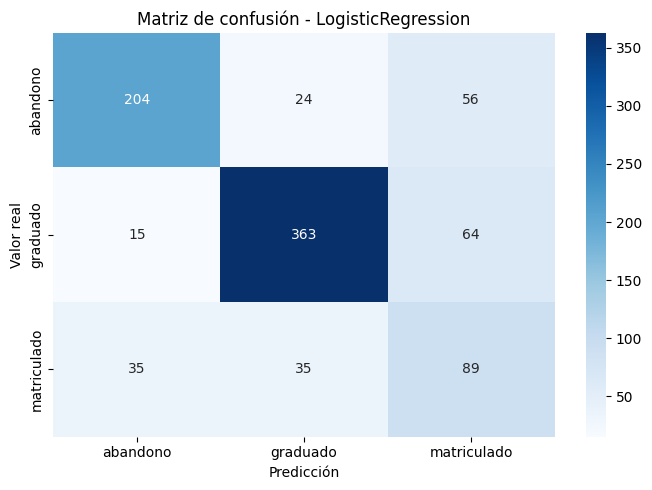

In [12]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.tight_layout()
plt.show()

## 11. Importancia de variables mediante permutation importance

Para interpretar el modelo final se utiliza `permutation_importance`. Esta técnica mide cuánto empeora el rendimiento del modelo cuando los valores de una variable se mezclan aleatoriamente.

Si al alterar una variable el rendimiento baja mucho, significa que esa variable es importante para el modelo. En este caso se utiliza `F1-macro` como métrica de evaluación.

In [13]:
result = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

importancias = pd.DataFrame({
    "variable": X_test.columns,
    "importancia_media": result.importances_mean,
    "importancia_std": result.importances_std
}).sort_values(by="importancia_media", ascending=False)

print("Top 10 variables más importantes:")
importancias.head(10)

Top 10 variables más importantes:


,variable,importancia_media,importancia_std
30,asignaturas_2sem_aprobadas,0.189206,0.012078
24,asignaturas_1sem_aprobadas,0.123957,0.011219
28,asignaturas_2sem_matriculadas,0.047054,0.009982
16,matricula_al_dia,0.037774,0.007641
3,curso,0.032131,0.007681
31,nota_media_2sem,0.026386,0.006132
22,asignaturas_1sem_matriculadas,0.017611,0.006471
29,asignaturas_2sem_evaluadas,0.014655,0.006953
9,cualificacion_padre,0.014320,0.003171
1,modo_solicitud,0.010986,0.007415


## 13. Conclusión del análisis

Este notebook permite comparar distintos modelos de clasificación para predecir la situación final del estudiante. La validación cruzada permite seleccionar el modelo más robusto y la evaluación en test proporciona una estimación de su capacidad de generalización.

Además, la matriz de confusión ayuda a identificar las clases más difíciles de predecir, mientras que la permutation importance permite interpretar qué variables son más relevantes para el modelo final.